# Classification Model: Logistic Regression

Linear regression model assumes that the response variable Y is quantitative 
eye color: blue, green, or brown; 
But in many case, response variable is qualitative: market movement: up/down

Qualitative variables are also referred as categorical

In this section, we study approaches for predicting qualitative responses: a process that is known as classification

We discuss following classification techniques:
Logistic Regression

This program provides a simple exercise for Logistic Regression Ananlysis

References:
book: An Introduction to Statistical Learning, with Application in R,  by James, Witten, Hastie, and Tibshirani
coode: https://towardsdatascience.com/logistic-regression-python-7c451928efee

# Import the Libraries

In [8]:
## Imort the Libraires

import pandas as pd
import csv


import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as seabornInstance 
import statsmodels.api as sm

import statsmodels.formula.api as smf


from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn import metrics


# Generate a random Data

In [9]:
import sklearn.datasets as d      
import sklearn.datasets as d   
x, y = d.make_classification(
    n_samples=100,
    n_features=1,
    n_classes=2,
    n_clusters_per_class=1,
    flip_y=0.03,
    n_informative=1,
    n_redundant=0,
    n_repeated=0
)

# Check the data, type 


In [10]:
x[1]

array([-0.91810786])

In [11]:
y[1]

0

In [12]:
type(x)

numpy.ndarray

In [13]:
type(y)

numpy.ndarray

# Plot the relationship between the feature and classes.

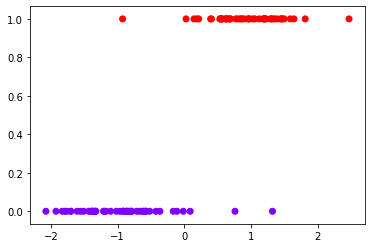

In [14]:
import matplotlib.pyplot as plt  
plt.scatter(x, y, c=y, cmap='rainbow')

# Split the data in training and test data

In [15]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=1)

# Fit the training data in Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

C:\Users\rashraf\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

# Print the Model Coeeficient and Intercept

In [17]:
print(lr.coef_)
print(lr.intercept_)

[[2.61796513]]
[0.04711267]


# Use the predict() function on the test features to predict classes on test data

In [18]:
y_pred = lr.predict(x_test)

# See the Confusion Matrix
Refer to [m,n] below to understand the type of error
True positive [1,1]:  (We predicted a positive result and it was positive)
True negative [2,2]:  (We predicted a negative result and it was negative)
False positive [1,2] : (We predicted a positive result and it was negative)
False negative [2,1]:  (We predicted a negative result and it was positive)


In [19]:
confusion_matrix(y_test, y_pred)

array([[13,  2],
       [ 0, 10]], dtype=int64)

# Accuracy of the model 

In [20]:
accuracy = np.mean(y_pred == y_test)
print ('accuracy = {0}%'.format(accuracy*100)  )

accuracy = 92.0%


Check the actual probability that a data point belongs to a given class, 
we can use the predict_proba function.

The first column corresponds to the probability that the sample belongs to the first class and the second column corresponds to the probability that the sample belongs to the second class.

In [21]:
lr.predict_proba(x_test)

array([[0.13524255, 0.86475745],
       [0.92270594, 0.07729406],
       [0.59658213, 0.40341787],
       [0.25363583, 0.74636417],
       [0.97246476, 0.02753524],
       [0.04156185, 0.95843815],
       [0.95801903, 0.04198097],
       [0.18242275, 0.81757725],
       [0.03031024, 0.96968976],
       [0.18109634, 0.81890366],
       [0.43184932, 0.56815068],
       [0.98797752, 0.01202248],
       [0.07106614, 0.92893386],
       [0.99040475, 0.00959525],
       [0.98976684, 0.01023316],
       [0.14245167, 0.85754833],
       [0.96900525, 0.03099475],
       [0.98255234, 0.01744766],
       [0.96978157, 0.03021843],
       [0.97284464, 0.02715536],
       [0.47186473, 0.52813527],
       [0.71340284, 0.28659716],
       [0.11565249, 0.88434751],
       [0.95389033, 0.04610967],
       [0.09109604, 0.90890396]])

# Plot the Sigmoid function to see the performace of the model 

Why Sigmoid: A Probabilistic Perspective: 
https://towardsdatascience.com/why-sigmoid-a-probabilistic-perspective-42751d82686
https://developers.google.com/machine-learning/crash-course/logistic-regression/calculating-a-probability

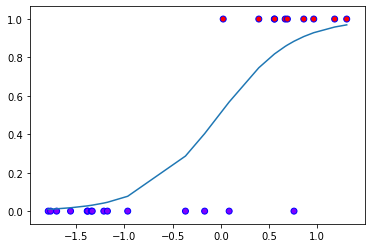

In [22]:
df = pd.DataFrame({'x': x_test[:,0], 'y': y_test})
df = df.sort_values(by='x')
from scipy.special import expit
sigmoid_function = expit(df['x'] * lr.coef_[0][0] + lr.intercept_[0]).ravel()
plt.plot(df['x'], sigmoid_function)
plt.scatter(df['x'], df['y'], c=df['y'], cmap='rainbow', edgecolors='b')